<a href="https://colab.research.google.com/github/pradp27/DSA0205-Computer-Vision-with-Open-CV/blob/main/20JUL26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

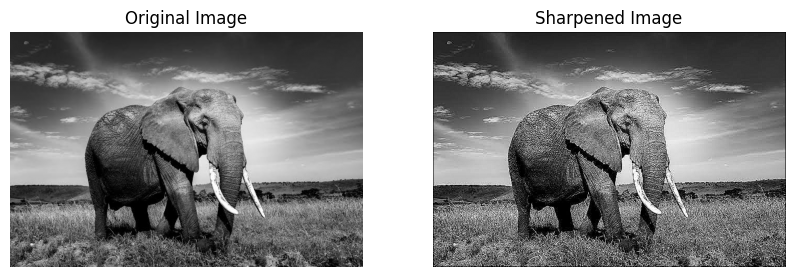

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image.jpg", 0)

if img is None:
    print("Error: Image not found!")
    exit()

img = img.astype(int)

rows, cols = img.shape

output = np.zeros((rows, cols), dtype=int)

kernel = [
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
]

for i in range(1, rows - 1):
    for j in range(1, cols - 1):

        value = 0

        for m in range(3):
            for n in range(3):

                pixel = img[i + m - 1][j + n - 1]
                value += pixel * kernel[m][n]

        if value < 0:
            value = 0
        elif value > 255:
            value = 255

        output[i][j] = value

img = img.astype(np.uint8)
output = output.astype(np.uint8)


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output, cmap='gray')
plt.title("Sharpened Image")
plt.axis("off")

plt.show()

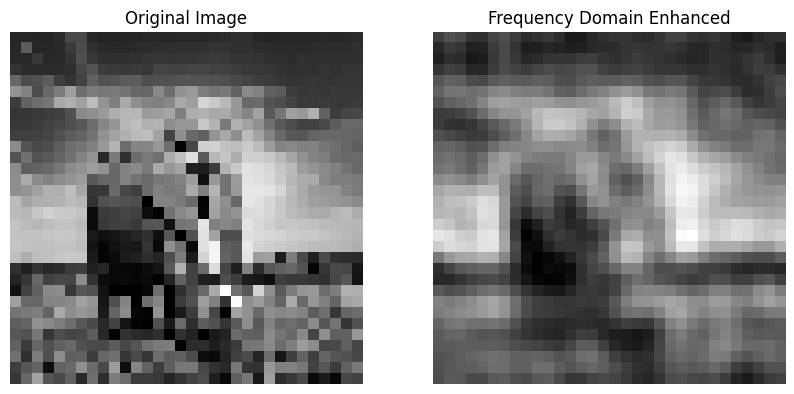

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

img = cv2.imread("image.jpg", 0)

if img is None:
    print("Image not found!")
    exit()

# Resize because manual DFT is very slow
img = cv2.resize(img, (32, 32))
img = img.astype(float)

M, N = img.shape

F = np.zeros((M, N), dtype=complex)

for u in range(M):
    for v in range(N):

        s = 0 + 0j

        for x in range(M):
            for y in range(N):

                angle = -2 * math.pi * ((u * x / M) + (v * y / N))

                s += img[x][y] * complex(math.cos(angle), math.sin(angle))

        F[u][v] = s

F_shift = np.zeros((M, N), dtype=complex)

halfM = M // 2
halfN = N // 2

for i in range(M):
    for j in range(N):
        ni = (i + halfM) % M
        nj = (j + halfN) % N
        F_shift[ni][nj] = F[i][j]

D0 = 8

for u in range(M):
    for v in range(N):

        D = math.sqrt((u - halfM) ** 2 + (v - halfN) ** 2)

        if D > D0:
            F_shift[u][v] = 0

F = np.zeros((M, N), dtype=complex)

for i in range(M):
    for j in range(N):
        ni = (i + halfM) % M
        nj = (j + halfN) % N
        F[i][j] = F_shift[ni][nj]

output = np.zeros((M, N))

for x in range(M):
    for y in range(N):

        s = 0 + 0j

        for u in range(M):
            for v in range(N):

                angle = 2 * math.pi * ((u * x / M) + (v * y / N))

                s += F[u][v] * complex(math.cos(angle), math.sin(angle))

        output[x][y] = abs(s) / (M * N)


output = np.clip(output, 0, 255).astype(np.uint8)
img = img.astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output, cmap='gray')
plt.title("Frequency Domain Enhanced")
plt.axis("off")

plt.show()